In [13]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots




In [14]:
df = pd.read_excel(
    r"D:\iec\ass1\python\portfolio2\66634-ev-data\Electric_Vehicle_Population_Data.csv"
)
df.head(2)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10


# Electric Vehicle Population Analysis

The objective of this project is to analyze electric vehicle (EV) adoption trends and distribution using registration data across different regions. It aims to examine patterns based on vehicle type, make, model year, and clean fuel eligibility. The study also explores geographic distribution to identify high and low adoption areas. The insights will support data-driven decisions for policy planning, infrastructure development, and market analysis

In [ ]:
# Show columns
numeric_cols = df.select_dtypes(include=['number'])
categorical_cols = df.select_dtypes(include=['object'])

summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Mean": numeric_cols.mean(),
   })

print(summary)


C:\Users\user\AppData\Local\Temp\ipykernel_12736\1531150531.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object'])


                                                   Missing Values Data Type  \
2020 Census Tract                                               5   float64   
Base MSRP                                                       0     int64   
City                                                            5       str   
Clean Alternative Fuel Vehicle (CAFV) Eligibility               0       str   
County                                                          5       str   
DOL Vehicle ID                                                  0     int64   
Electric Range                                                  0     int64   
Electric Utility                                                5       str   
Electric Vehicle Type                                           0       str   
Legislative District                                          389   float64   
Make                                                            0       str   
Model                                               

# 🚗 Electric Vehicle Dataset Column Description

| Column Name | Description |
|------------|-------------|
| VIN (1-10) | Unique Vehicle Identification Number (first 10 characters) used to identify each vehicle |
| County | County where the vehicle is registered, used for regional analysis |
| City | City of registration, helps in city-level EV distribution analysis |
| State | State of registration (e.g., WA = Washington) for state-wise EV trends |
| Postal Code | ZIP code of vehicle owner for geographic segmentation |
| Model Year | Year the vehicle was manufactured, used for trend analysis |
| Make | Manufacturer of the vehicle (e.g., TESLA, FORD) |
| Model | Specific vehicle model (e.g., MODEL Y, MODEL S) |
| Electric Vehicle Type | Type of EV (BEV = Battery Electric, PHEV = Plug-in Hybrid) |
| Clean Alternative Fuel Vehicle (CAFV) Eligibility | Indicates whether vehicle qualifies as clean fuel vehicle |
| Electric Range | Maximum electric-only driving range (in miles) |
| Base MSRP | Manufacturer Suggested Retail Price (base price of vehicle) |
| Legislative District | Government district for policy and regional analysis |
| DOL Vehicle ID | Unique ID assigned by Department of Licensing |
| Vehicle Location | Geographic coordinates of vehicle location |
| Electric Utility | Electricity provider supporting EV charging |
| 2020 Census Tract | Census geographic area used for demographic analysis | 

In [ ]:
total = df['Electric Vehicle Type'].notna().sum()

Bev_count = df['Electric Vehicle Type'].str.contains("BEV", na=False).sum()
Phev_count = df['Electric Vehicle Type'].str.contains("PHEV", na=False).sum()

Bevp = (Bev_count / total) * 100
Phevp = (Phev_count / total) * 100

top_make = df['Make'].value_counts().idxmax()
top_state = df['State'].value_counts().idxmax()
top_county = df['County'].value_counts().idxmax()
top_city = df['City'].value_counts().idxmax()
top_model = df['Model'].value_counts().idxmax()


print("Total Vehicle Registered:", df['DOL Vehicle ID'].count())

print("BEV Total EVs:", Bev_count)

print("PHEV Total EVs:", Phev_count)

print("BEV %:", round(Bevp, 2))

print("PHEV %:", round(Phevp, 2))

print("Top Maker:", top_make)

print("Top Model:", top_model)

print("Top State:", top_state)

print("Top City:", top_city)

print("Top County:", top_county)

print(
    "Electric Range:",
    df[df["Electric Range"] > 0]["Electric Range"].value_counts().idxmax()
)



Total Vehicle Registered: 177866
BEV Total EVs: 139210
PHEV Total EVs: 38656
BEV %: 78.27
PHEV %: 21.73
Top Maker: TESLA
Top Model: MODEL Y
Top State: WA
Top City: Seattle
Top County: King
Electric Range: 215


# Bussiness Question
* How is the EV market split between BEV and PHEV, and how has it evolved over time?
* How well does the current EV fleet comply with Clean Alternative Fuel Vehicle (CAFV) eligibility requirements?
* Which manufacturers lead the EV market, and how concentrated is market share?
* How is EV adoption distributed across states, counties, and cities?
* How does EV adoption differ between urban and rural areas, and what does this reveal about infrastructure readiness?
* How has electric range improved across manufacturers and model years?

## BEV vs PHEV Trend (2010–2024)

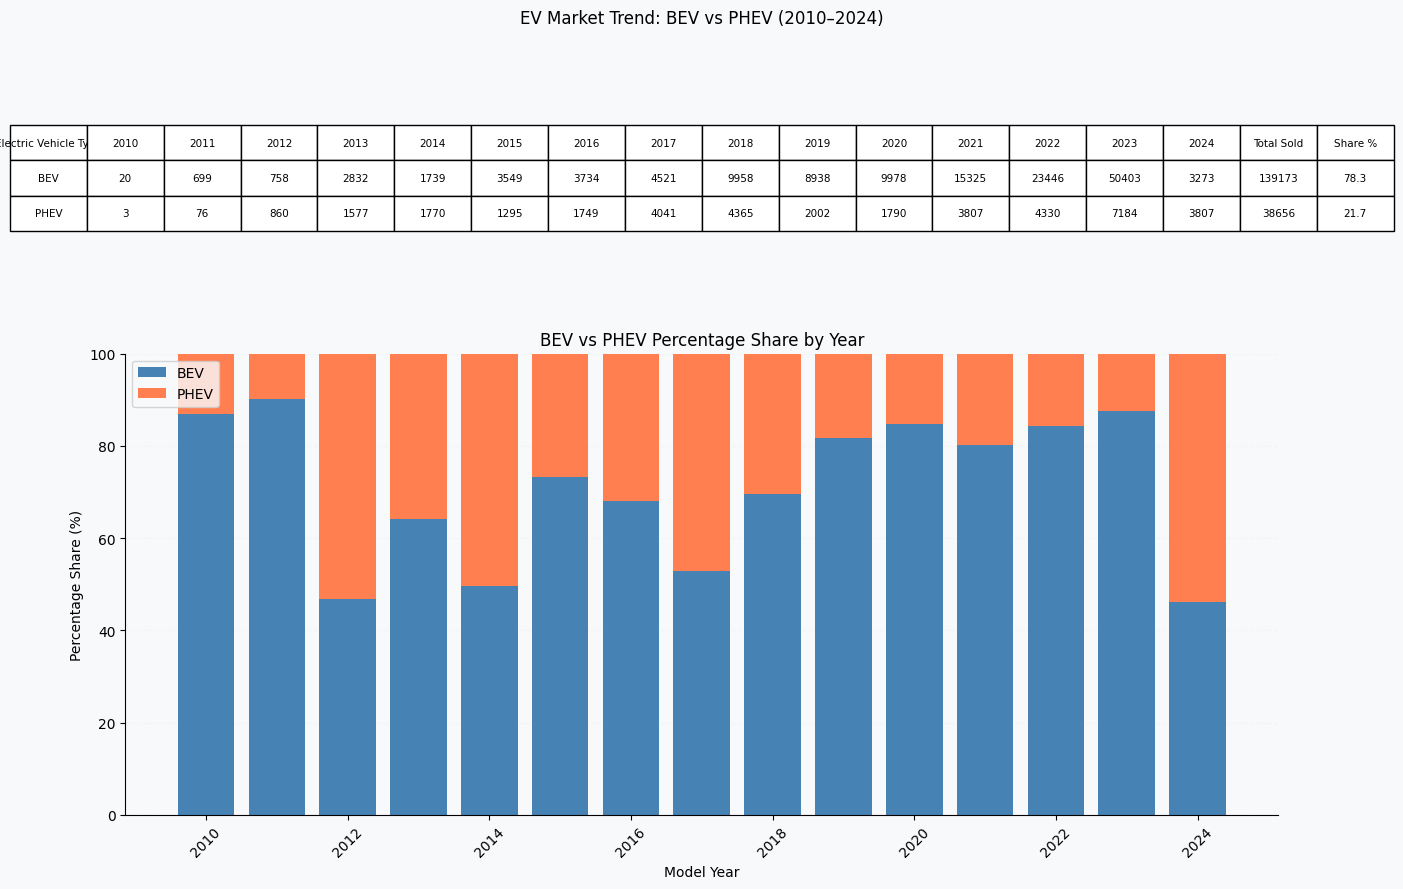

In [ ]:
import matplotlib.pyplot as plt

# ---------------- FILTER YEARS ----------------

years_range = list(range(2010, 2025))

filtered_df = df[df['Model Year'].isin(years_range)].copy()

# ---------------- CLEAN EV TYPE NAMES ----------------

filtered_df['Electric Vehicle Type'] = (
    filtered_df['Electric Vehicle Type']
    .replace({
        'Battery Electric Vehicle (BEV)': 'BEV',
        'Plug-in Hybrid Electric Vehicle (PHEV)': 'PHEV'
    })
)

# ---------------- TABLE DATA ----------------

sales_table = (
    filtered_df
    .groupby(['Electric Vehicle Type', 'Model Year'])
    .size()
    .reset_index(name='Count')
)

pivot_table = (
    sales_table
    .pivot(
        index='Electric Vehicle Type',
        columns='Model Year',
        values='Count'
    )
    .fillna(0)
    .astype(int)
)

# ---------------- TOTAL & SHARE ----------------

pivot_table['Total Sold'] = pivot_table.sum(axis=1)

grand_total = pivot_table['Total Sold'].sum()

pivot_table['Share %'] = (
    pivot_table['Total Sold'] / grand_total * 100
).round(1)

pivot_table = pivot_table.reset_index()

# ---------------- YEARLY SHARE % ----------------

trend = (
    filtered_df
    .groupby(['Model Year', 'Electric Vehicle Type'])
    .size()
    .reset_index(name='Count')
)

trend_pivot = (
    trend
    .pivot(
        index='Model Year',
        columns='Electric Vehicle Type',
        values='Count'
    )
    .fillna(0)
)

# Convert to percentage
trend_share = (
    trend_pivot.div(trend_pivot.sum(axis=1), axis=0) * 100
)

# ---------------- FIGURE LAYOUT ----------------

fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 9),
    gridspec_kw={'height_ratios': [1.2, 2]}
)


axes[0].axis('off')

table = axes[0].table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1.2, 1.8)

axes[0].set_title(
    "EV Market Trend: BEV vs PHEV (2010–2024)",
    fontsize=12,
    pad=12
)

years = trend_share.index

bev_percent = trend_share['BEV']
phev_percent = trend_share['PHEV']

axes[1].bar(
    years,
    bev_percent,
    color='steelblue',
    label='BEV'
)

axes[1].bar(
    years,
    phev_percent,
    bottom=bev_percent,
    color='coral',
    label='PHEV'
)

# ---------------- FORMATTING ----------------

axes[1].set_title("BEV vs PHEV Percentage Share by Year")
axes[1].set_xlabel("Model Year")
axes[1].set_ylabel("Percentage Share (%)")

axes[1].set_ylim(0, 100)

axes[1].tick_params(axis='x', rotation=45)

axes[1].legend(loc='upper left')

axes[1].grid(axis='y', linestyle='--', alpha=0.2)

axes[1].set_axisbelow(True)

# =========================================================

plt.tight_layout()
plt.show()

## Overall CAFV Eligibility Distribution

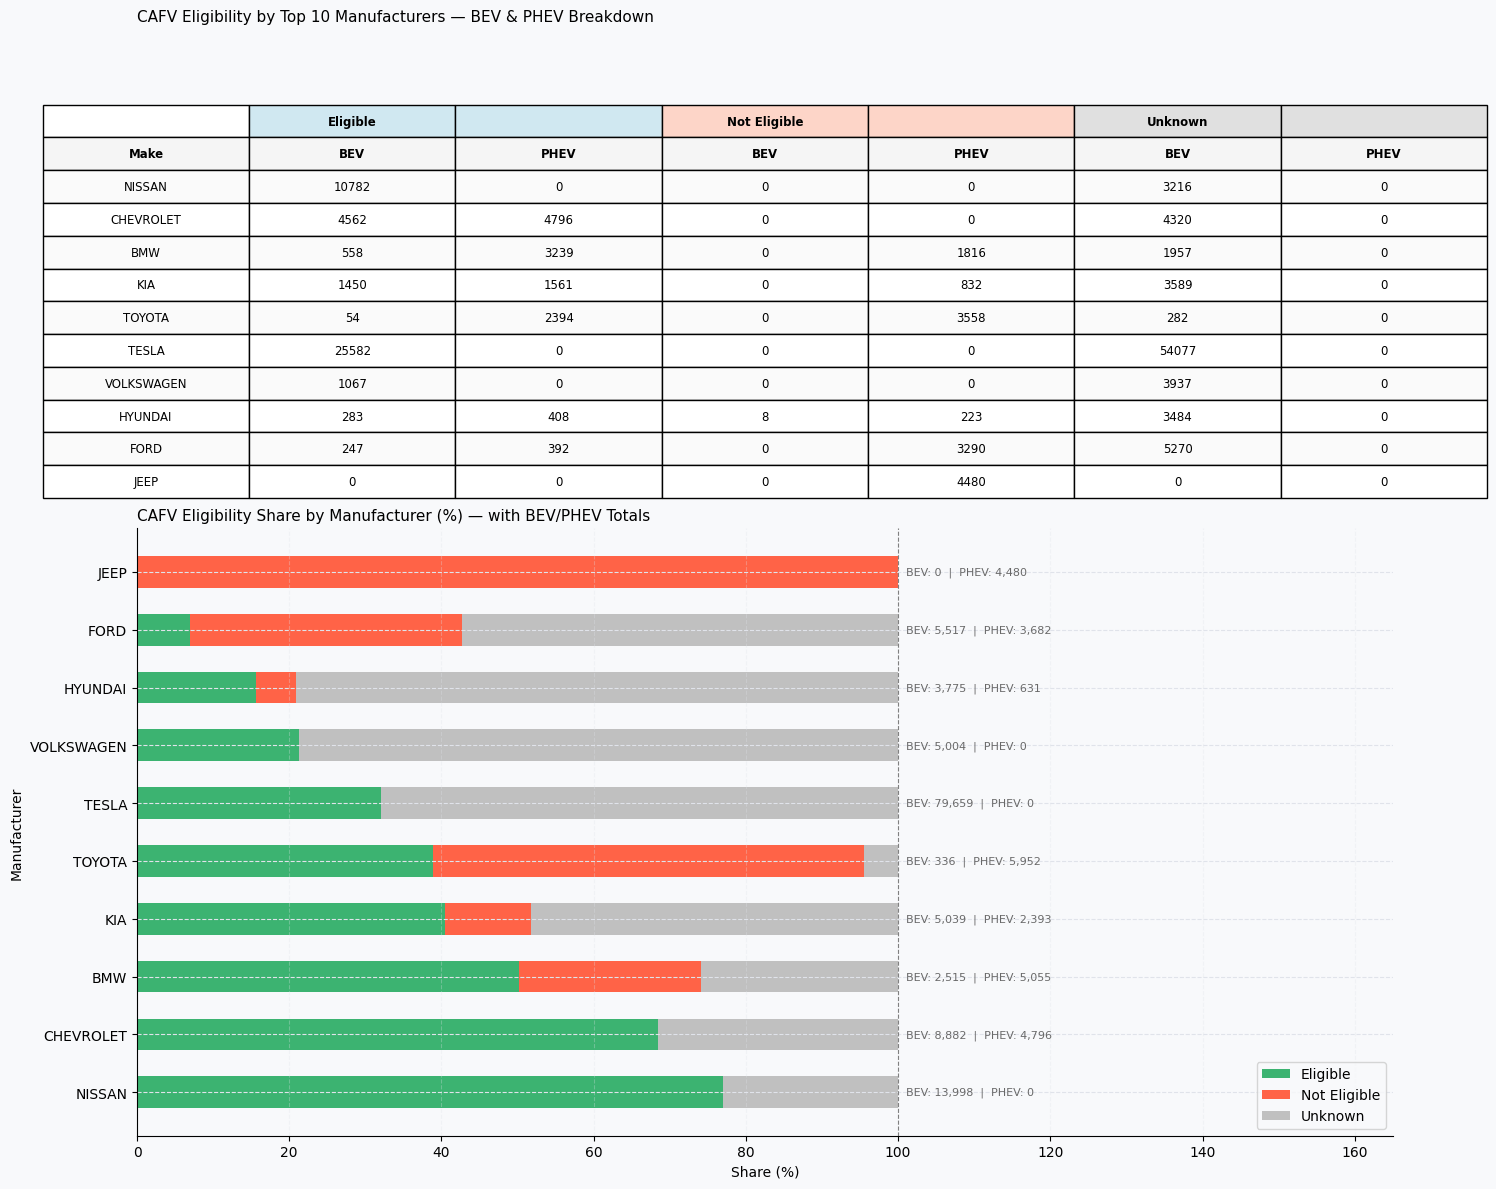

In [ ]:
# ── Run this cell FIRST before any analysis ───────────────────────────────────

df['CAFV'] = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].replace({
    'Clean Alternative Fuel Vehicle Eligible'                      : 'Eligible',
    'Not eligible due to low battery range'                        : 'Not Eligible',
    'Eligibility unknown as battery range has not been researched' : 'Unknown'
})

df['Electric Vehicle Type'] = df['Electric Vehicle Type'].replace({
    'Battery Electric Vehicle (BEV)'         : 'BEV',
    'Plug-in Hybrid Electric Vehicle (PHEV)' : 'PHEV'
})

COLORS = ['steelblue', 'coral', 'mediumseagreen']

# ══════════════════════════════════════════════════════════════════════════════
# ANALYSIS  — CAFV Eligibility by Top 10 Manufacturers (with EV Type)
# ══════════════════════════════════════════════════════════════════════════════
top10_makes = df['Make'].value_counts().head(10).index
make_df = df[df['Make'].isin(top10_makes)]

# --- Multi-level crosstab: Make × (CAFV → EV Type) ---
multi_cross = pd.crosstab(
    make_df['Make'],
    [make_df['CAFV'], make_df['Electric Vehicle Type']]
).fillna(0).astype(int)

# --- CAFV share per make (for chart) ---
cafv_make     = pd.crosstab(make_df['Make'], make_df['CAFV'])
cafv_make_pct = cafv_make.div(cafv_make.sum(axis=1), axis=0) * 100

if 'Eligible' in cafv_make_pct.columns:
    cafv_make_pct = cafv_make_pct.sort_values('Eligible', ascending=False)

sorted_makes = cafv_make_pct.index
multi_cross  = multi_cross.loc[sorted_makes]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 12),
                         gridspec_kw={'height_ratios': [1.2, 2]})

# ── TABLE (top) with two-row header ──────────────────────────────────────────
axes[0].axis('off')
axes[0].set_title(
    'CAFV Eligibility by Top 10 Manufacturers — BEV & PHEV Breakdown',
    fontsize=11, loc='left', pad=55
)

# Build flat cell values
cell_vals = []
for make in sorted_makes:
    row = [make]
    for cafv_cat in ['Eligible', 'Not Eligible', 'Unknown']:
        for ev in ['BEV', 'PHEV']:
            try:
                row.append(multi_cross.loc[make, (cafv_cat, ev)])
            except KeyError:
                row.append(0)
    cell_vals.append(row)

# ── Draw table manually to support two-row header ────────────────────────────
col_labels_row1 = ['',       'Eligible', '',    'Not Eligible', '',    'Unknown', ''   ]
col_labels_row2 = ['Make',   'BEV',      'PHEV','BEV',          'PHEV','BEV',     'PHEV']

n_cols   = len(col_labels_row2)
n_rows   = len(cell_vals)
col_w    = 1 / n_cols
row_h    = 0.12

header_colors = {
    'Eligible'    : '#d0e8f1',
    'Not Eligible': '#fdd5c8',
    'Unknown'     : '#e0e0e0',
    ''            : 'white'
}
sub_header_color = '#f5f5f5'

tbl = axes[0].table(
    cellText=[col_labels_row1, col_labels_row2] + cell_vals,
    loc='upper center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.15, 1.7)

# Style row 0 — main headers
main_col_map = {1: 'Eligible', 2: 'Eligible',
                3: 'Not Eligible', 4: 'Not Eligible',
                5: 'Unknown', 6: 'Unknown'}

for col_idx in range(n_cols):
    cell = tbl[0, col_idx]
    cat  = main_col_map.get(col_idx, '')
    cell.set_facecolor(header_colors.get(cat, 'white'))
    cell.set_text_props(fontweight='bold')

# Style row 1 — sub headers (BEV / PHEV)
for col_idx in range(n_cols):
    tbl[1, col_idx].set_facecolor(sub_header_color)
    tbl[1, col_idx].set_text_props(fontweight='bold')

# Style data rows — alternate shading
for row_idx in range(2, n_rows + 2):
    bg = '#fafafa' if row_idx % 2 == 0 else 'white'
    for col_idx in range(n_cols):
        tbl[row_idx, col_idx].set_facecolor(bg)

# ── STACKED HORIZONTAL BAR CHART (bottom) ────────────────────────────────────
bar_colors = {
    'Eligible'    : 'mediumseagreen',
    'Not Eligible': 'tomato',
    'Unknown'     : 'silver'
}

cafv_cols    = [c for c in ['Eligible', 'Not Eligible', 'Unknown'] if c in cafv_make_pct.columns]
y_positions  = list(range(len(sorted_makes)))

bottom = None
for col in cafv_cols:
    vals = cafv_make_pct.loc[sorted_makes, col]
    axes[1].barh(y_positions, vals,
                 label=col, color=bar_colors[col], left=bottom, height=0.55)
    bottom = vals if bottom is None else bottom + vals

# Annotate BEV / PHEV totals per make
for i, make in enumerate(sorted_makes):
    bev_total  = sum(multi_cross.loc[make, (cat, 'BEV')]
                     for cat in cafv_cols if (cat, 'BEV') in multi_cross.columns)
    phev_total = sum(multi_cross.loc[make, (cat, 'PHEV')]
                     for cat in cafv_cols if (cat, 'PHEV') in multi_cross.columns)
    axes[1].text(
        101, i,
        f"BEV: {int(bev_total):,}  |  PHEV: {int(phev_total):,}",
        va='center', fontsize=8, color='dimgray'
    )

axes[1].set_title('CAFV Eligibility Share by Manufacturer (%) — with BEV/PHEV Totals',
                  fontsize=11, loc='left')
axes[1].set_xlabel('Share (%)')
axes[1].set_ylabel('Manufacturer')
axes[1].set_xlim(0, 165)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(sorted_makes)
axes[1].legend(loc='lower right')
axes[1].grid(axis='x', alpha=0.3)
axes[1].axvline(x=100, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# Maker Sales Breakdown by Year

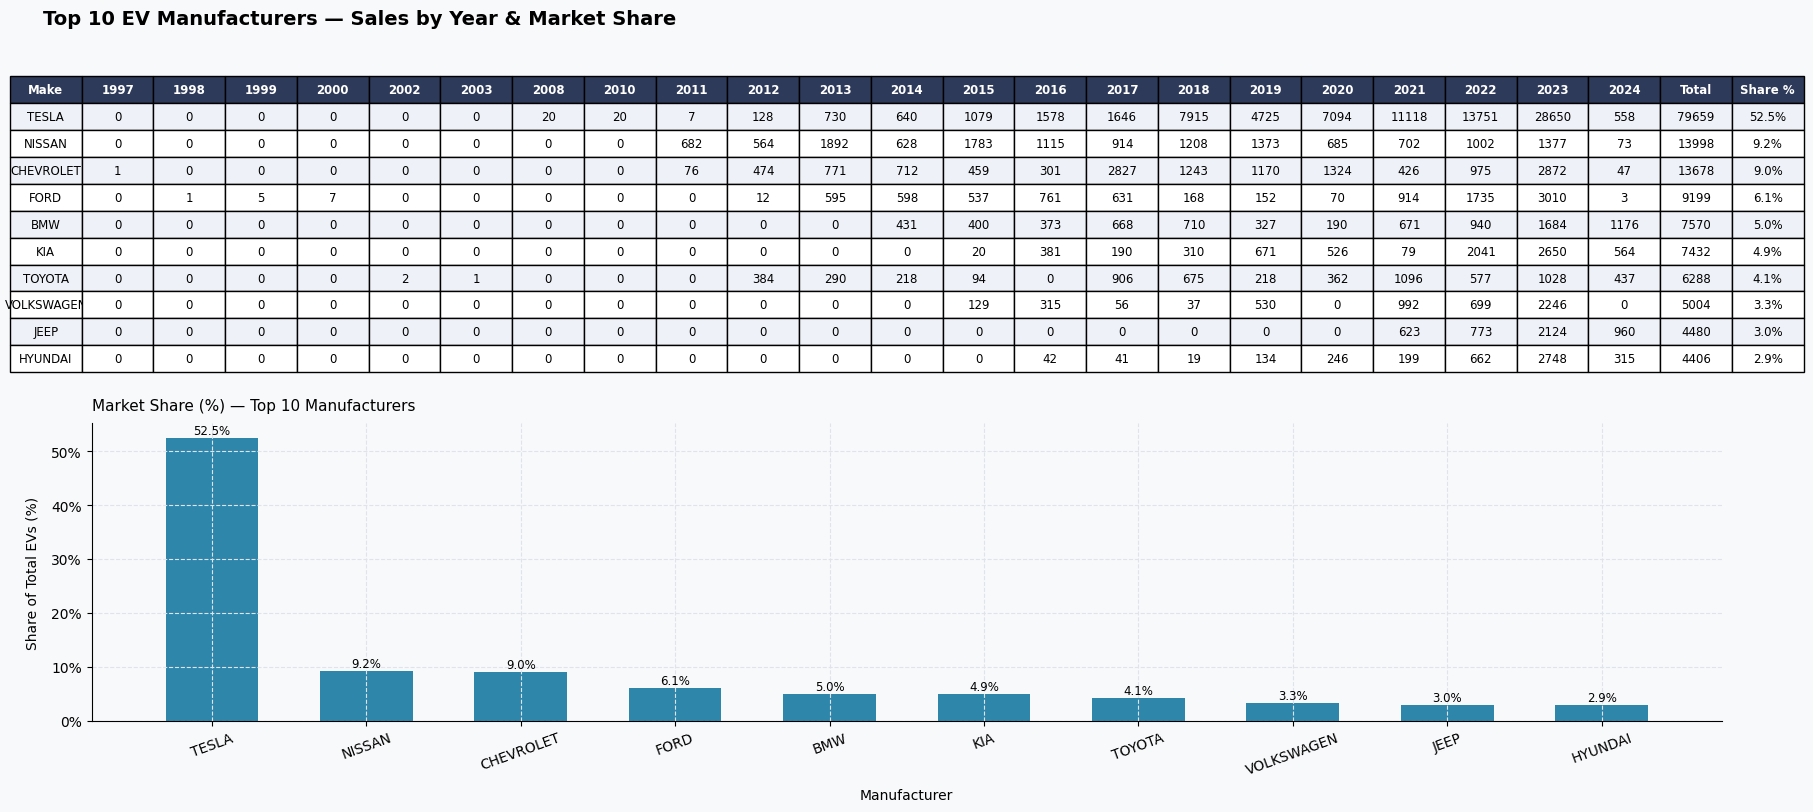

In [15]:
plt.rcParams.update({
    "figure.facecolor": "#F8F9FB",
    "axes.facecolor":   "#F8F9FB",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#E0E3EA",
    "grid.linestyle":   "--",
    "font.family":      "DejaVu Sans",
    "font.size":        10,
})

# ── 1. Build pivot table ──────────────────────────────────────────────────────
top10      = df['Make'].value_counts().head(10).index
df_top10   = df[df['Make'].isin(top10)]

pivot = pd.pivot_table(
    df_top10,
    values='DOL Vehicle ID',
    index='Make',
    columns='Model Year',
    aggfunc='count',
    fill_value=0
)
pivot.columns = pivot.columns.astype(int)
pivot['Total'] = pivot.sum(axis=1)
pivot['Share %'] = (pivot['Total'] / pivot['Total'].sum() * 100).map('{:.1f}%'.format)
pivot = pivot.sort_values('Total', ascending=False)
table_df = pivot.reset_index()

# ── 2. Draw figure ────────────────────────────────────────────────────────────
fig, (ax_tbl, ax_bar) = plt.subplots(
    2, 1, figsize=(18, 8),
    gridspec_kw={'height_ratios': [1.2, 2]}
)
fig.suptitle(
    "Top 10 EV Manufacturers — Sales by Year & Market Share",
    fontsize=14, fontweight='bold', x=0.02, ha='left', y=1.01
)

# -- Table --
ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText  = table_df.values,
    colLabels = table_df.columns,
    loc       = 'center',
    cellLoc   = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.1, 1.9)

for c in range(len(table_df.columns)):         # dark header
    tbl[0, c].set_facecolor('#2E3A59')
    tbl[0, c].set_text_props(color='white', fontweight='bold')
for r in range(1, len(table_df) + 1):          # zebra rows
    bg = '#FFFFFF' if r % 2 == 0 else '#EEF1F7'
    for c in range(len(table_df.columns)):
        tbl[r, c].set_facecolor(bg)

# -- Bar chart: market share % --
share_vals = (pivot['Total'] / pivot['Total'].sum() * 100).values
bars = ax_bar.bar(pivot.index, share_vals, color='#2E86AB', width=0.6)

for bar in bars:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.2,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=8.5)

ax_bar.set_title('Market Share (%) — Top 10 Manufacturers', fontsize=11, loc='left', pad=10)
ax_bar.set_xlabel('Manufacturer', labelpad=8)
ax_bar.set_ylabel('Share of Total EVs (%)', labelpad=8)
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax_bar.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()



## Tesla Vs Others 

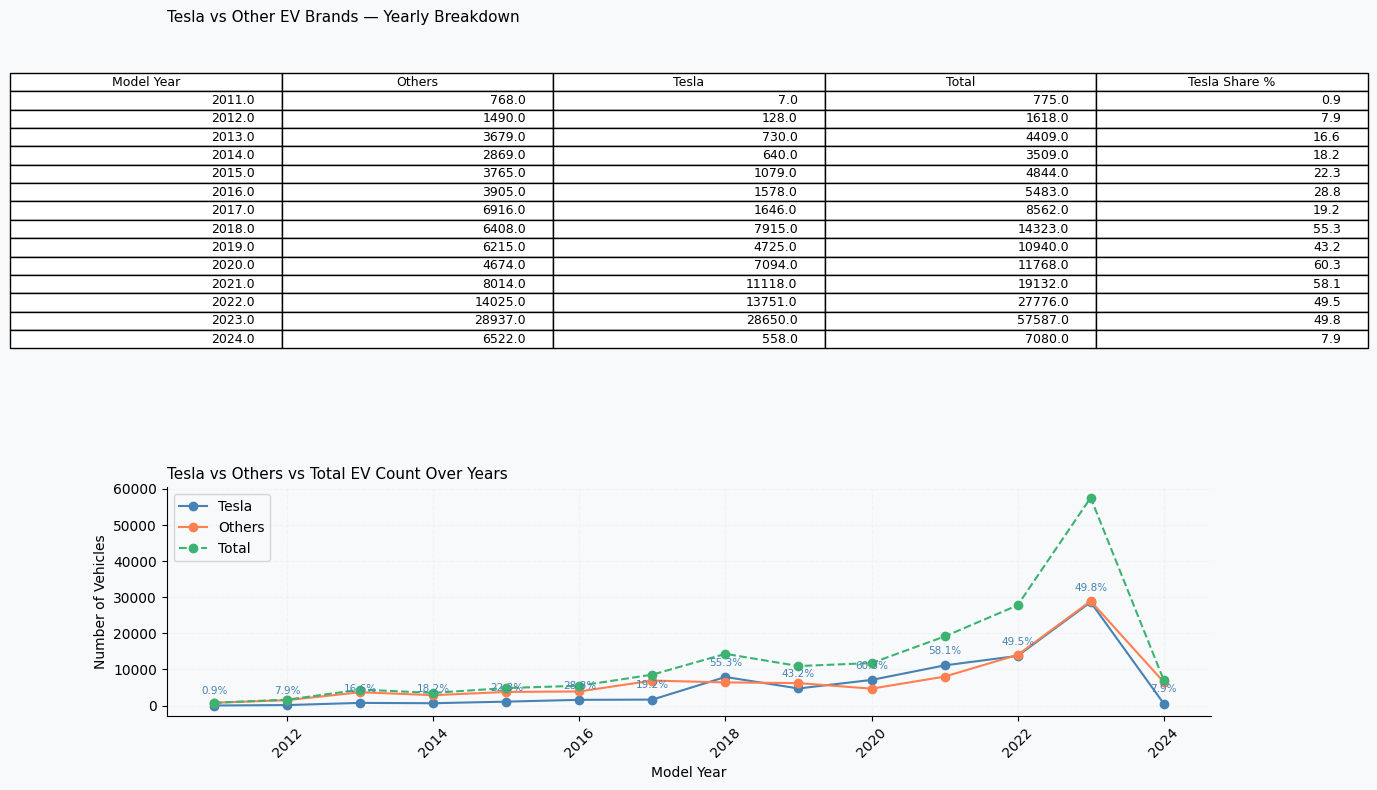

In [ ]:
df['Category'] = df['Make'].apply(lambda x: 'Tesla' if x.upper() == 'TESLA' else 'Others')

# Group by Year and Category
comparison = (
    df[df['Model Year'] > 2010]
    .groupby(['Model Year', 'Category'])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)
)

# Add total and share %
comparison['Total']       = comparison.sum(axis=1)
comparison['Tesla Share %'] = (comparison['Tesla'] / comparison['Total'] * 100).round(1)

table_df = comparison.reset_index()

# ── Figure: table on top, chart below ────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                         gridspec_kw={'height_ratios': [1, 2]})

# ── TABLE (top) ───────────────────────────────────────────────────────────────
axes[0].axis('off')
axes[0].set_title(
    'Tesla vs Other EV Brands — Yearly Breakdown',
    fontsize=11, loc='left', pad=35
)

tbl = axes[0].table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='upper center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 1.8)

# ── LINE CHART (bottom) ───────────────────────────────────────────────────────
years = comparison.index

axes[1].plot(years, comparison['Tesla'],  marker='o', label='Tesla',  color='steelblue')
axes[1].plot(years, comparison['Others'], marker='o', label='Others', color='coral')
axes[1].plot(years, comparison['Total'],  marker='o', label='Total',  color='mediumseagreen',
             linestyle='--')

# Annotate Tesla share % on each point
for year, row in comparison.iterrows():
    axes[1].annotate(
        f"{row['Tesla Share %']}%",
        xy=(year, row['Tesla']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=7.5,
        color='steelblue'
    )

axes[1].set_title('Tesla vs Others vs Total EV Count Over Years', fontsize=11, loc='left')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Number of Vehicles')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Geographic Analysis — EV Distribution by Top State, County & City
---

## Urban vs Rural EV Adoption Analysis Based on EV Registration Frequency

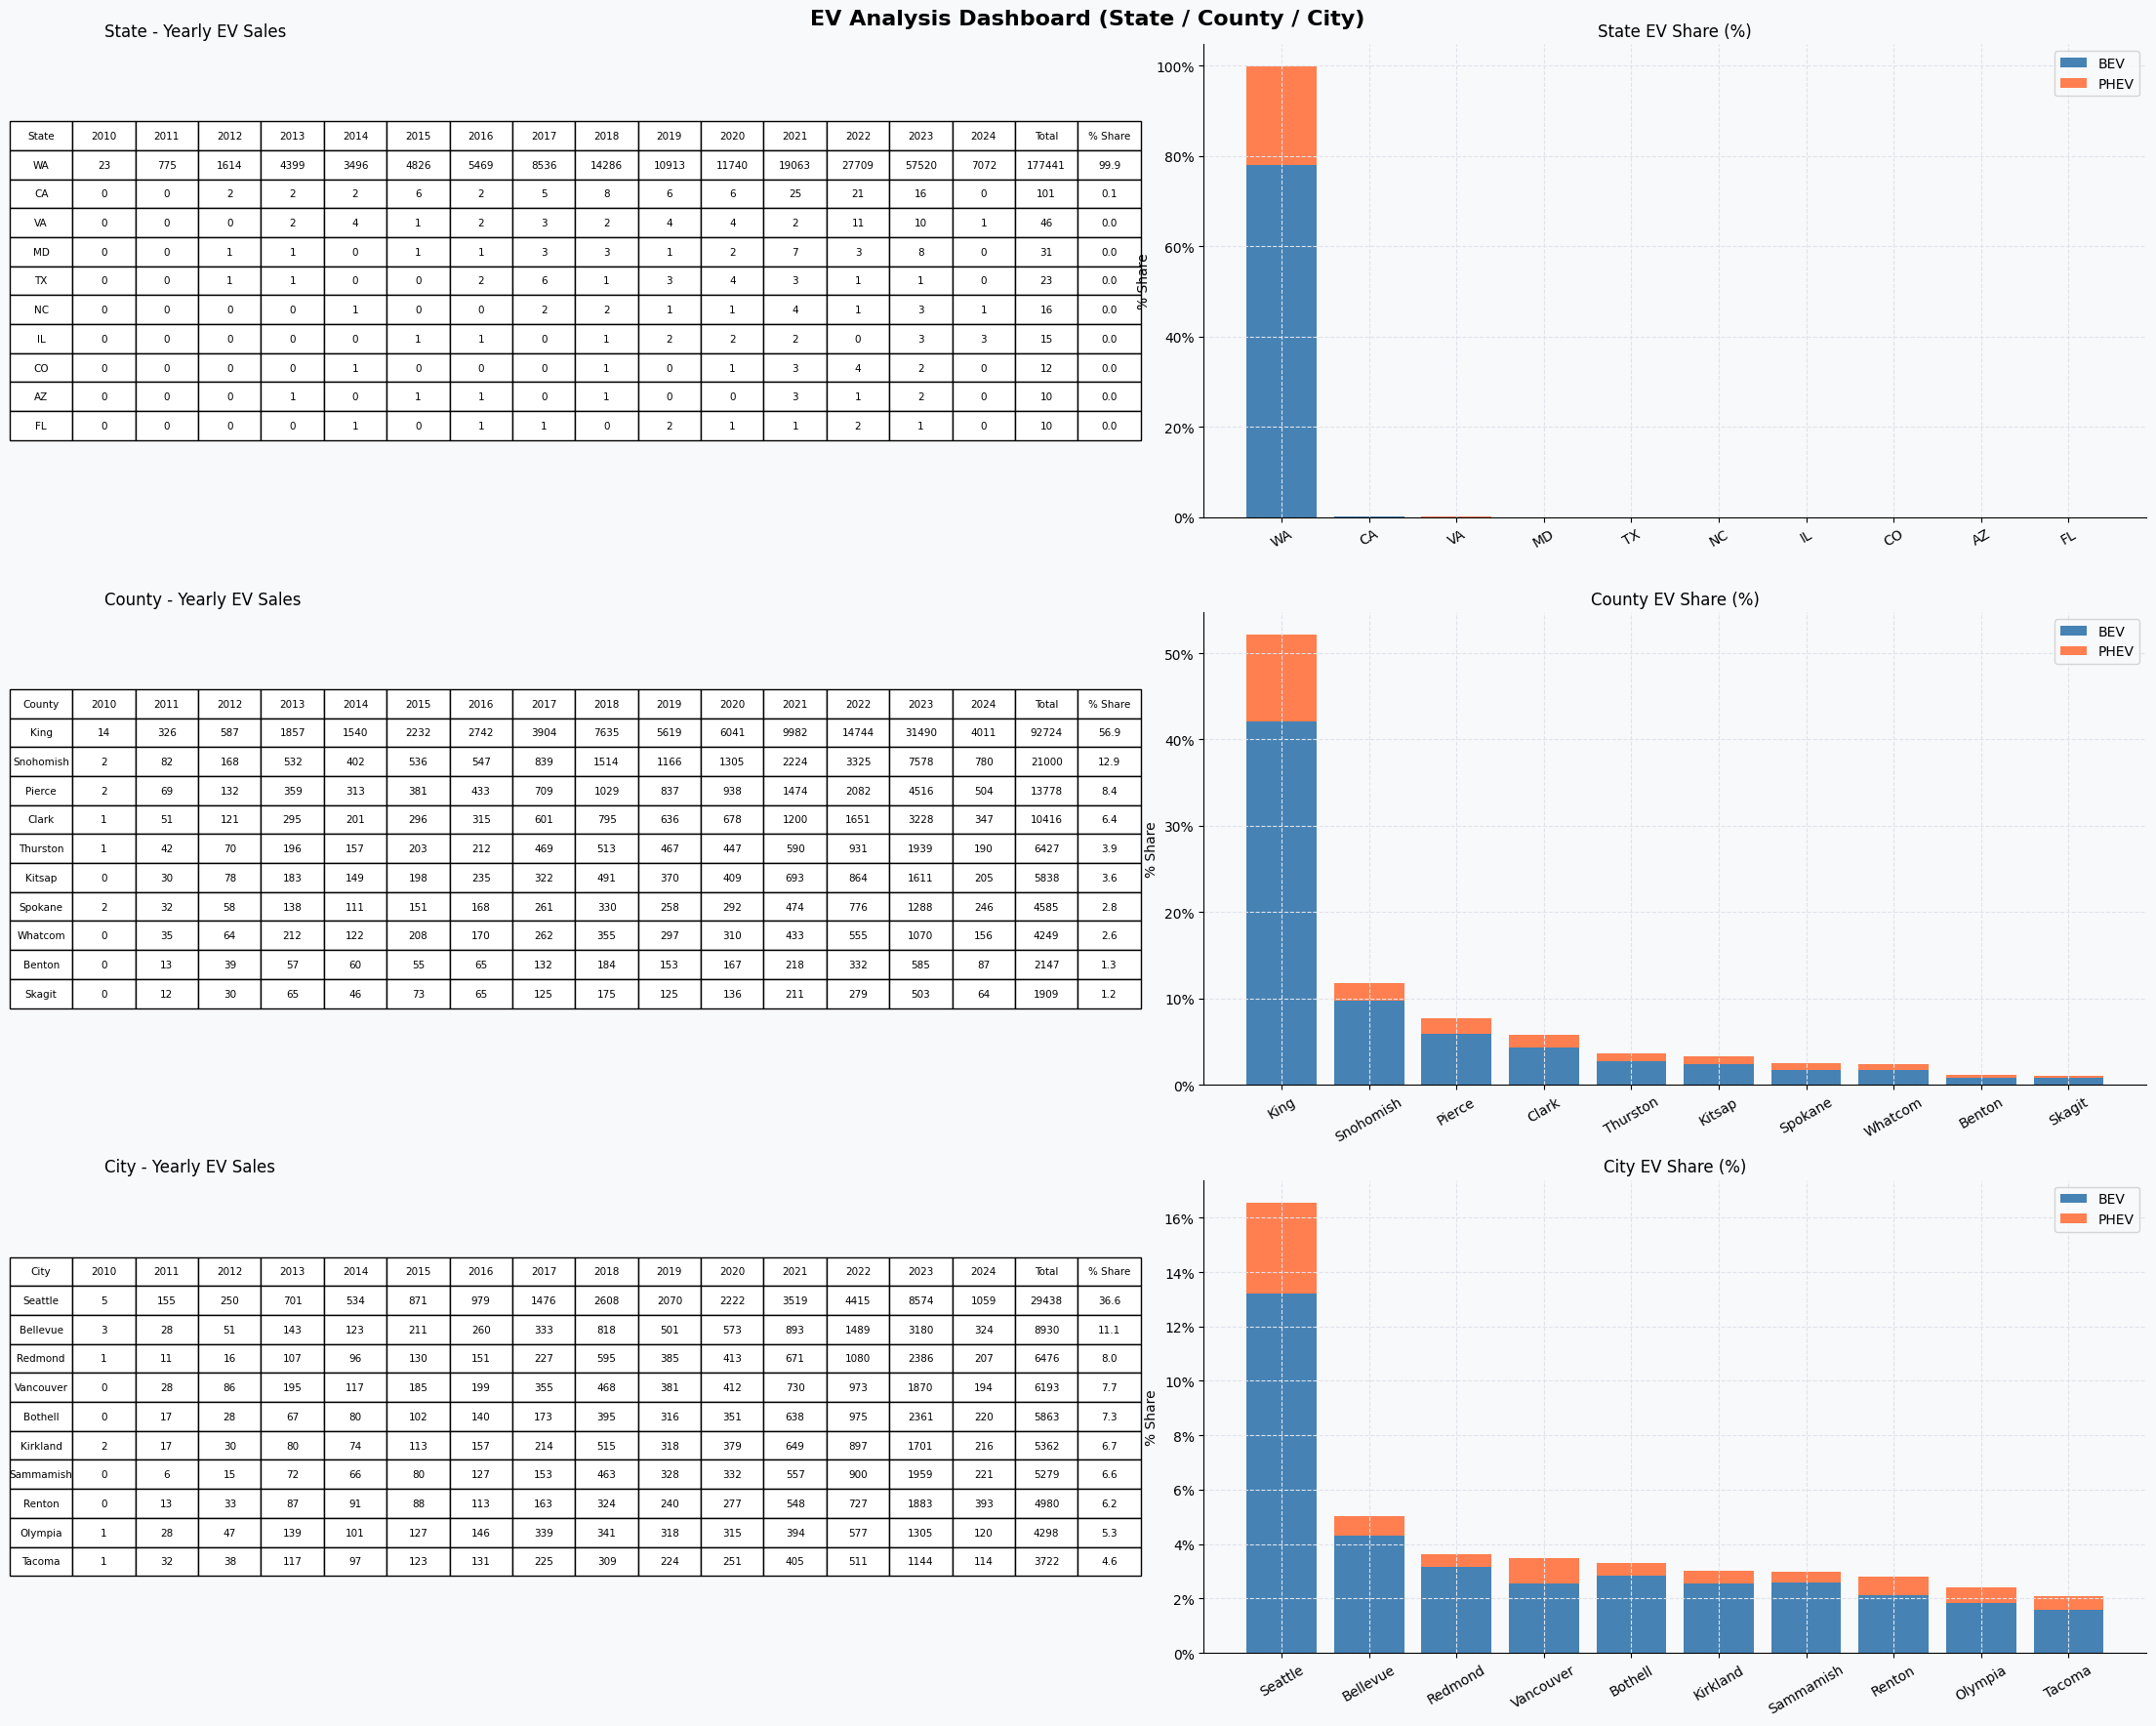

In [19]:
BEV = "Battery Electric Vehicle (BEV)"
PHEV = "Plug-in Hybrid Electric Vehicle (PHEV)"

# ================= FUNCTION FOR TABLE =================
def make_table(df, group_col):

    top = df[group_col].value_counts().head(10).index
    sub = df[df[group_col].isin(top)]

    pivot = sub.groupby([group_col, "Model Year"]).size().unstack(fill_value=0)
    pivot = pivot.loc[top]
    pivot = pivot[[c for c in pivot.columns if c >= 2010]]

    pivot["Total"] = pivot.sum(axis=1)
    pivot["% Share"] = (pivot["Total"] / pivot["Total"].sum() * 100).round(1)

    return pivot.reset_index()

# ================= FUNCTION FOR BAR =================
def make_bar_data(df, group_col):

    top = df[group_col].value_counts().head(10).index
    sub = df[df[group_col].isin(top)]

    bev = sub[sub["Electric Vehicle Type"] == BEV][group_col].value_counts().reindex(top, fill_value=0)
    phev = sub[sub["Electric Vehicle Type"] == PHEV][group_col].value_counts().reindex(top, fill_value=0)

    # 🔥 GLOBAL TOTAL (this is the key fix)
    global_total = len(df)

    bev_pct = (bev / global_total * 100)
    phev_pct = (phev / global_total * 100)

    return top, bev_pct, phev_pct


# ================= CREATE FIGURE =================
fig, axes = plt.subplots(3, 2, figsize=(22, 18))
fig.suptitle("EV Analysis Dashboard (State / County / City)", fontsize=16, fontweight="bold")

groups = ["State", "County", "City"]

for i, col in enumerate(groups):

    # ---------- TABLE ----------
    table_df = make_table(df, col)

    axes[i, 0].axis("off")
    axes[i, 0].set_title(f"{col} - Yearly EV Sales", loc="left")

    tbl = axes[i, 0].table(
        cellText=table_df.values,
        colLabels=table_df.columns,
        cellLoc="center",
        loc="center"
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.scale(1.2, 1.5)

    # ---------- BAR ----------
    labels, bev_pct, phev_pct = make_bar_data(df, col)

    axes[i, 1].bar(labels, bev_pct, label="BEV", color="steelblue")
    axes[i, 1].bar(labels, phev_pct, bottom=bev_pct, label="PHEV", color="coral")

    axes[i, 1].set_title(f"{col} EV Share (%)")
    axes[i, 1].set_ylabel("% Share")
    axes[i, 1].tick_params(axis="x", rotation=30)
    axes[i, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## Urban vs Rural EV Adoption

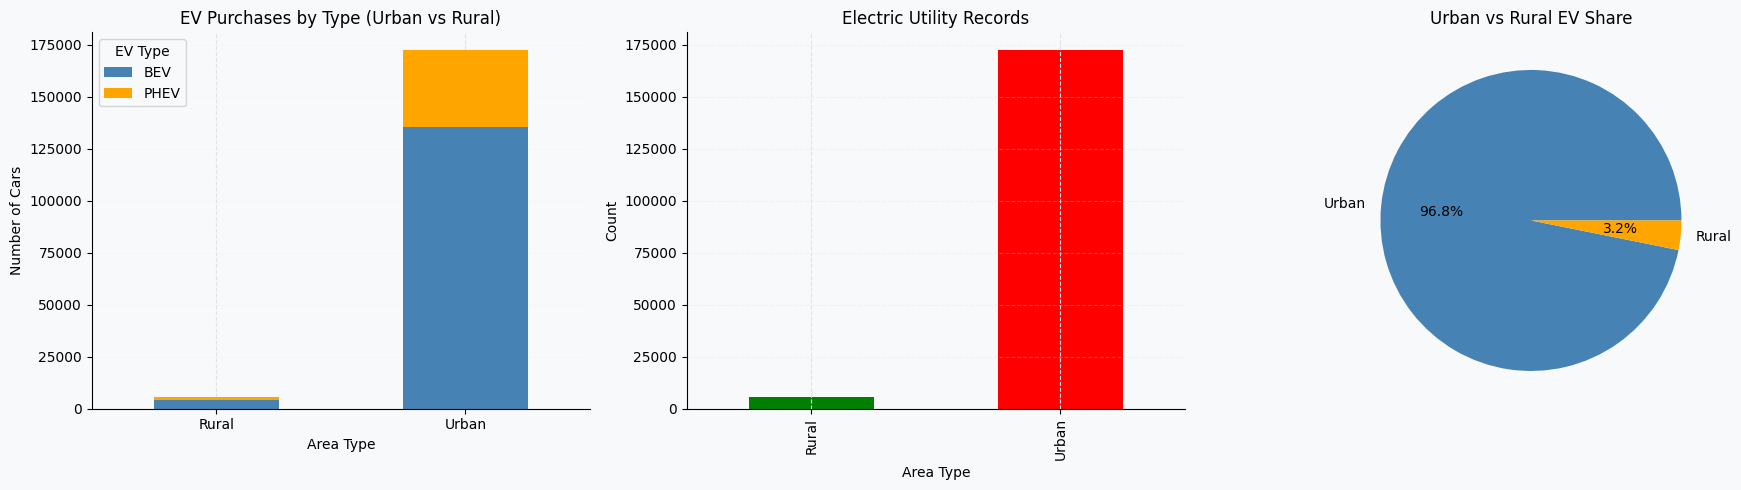

In [18]:
# ---------------- URBAN vs RURAL CLASSIFICATION ----------------

city_counts = df["City"].value_counts()

# Cities with 100+ EV records = Urban
urban_cities = set(city_counts[city_counts >= 80].index)

# Create new column
df["Area Type"] = df["City"].apply(
    lambda x: "Urban" if x in urban_cities else "Rural"
)


ev_pivot = df.groupby(["Area Type", "Electric Vehicle Type"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]

ev_pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["steelblue", "orange"]
)

ax.set_title("EV Purchases by Type (Urban vs Rural)")
ax.set_ylabel("Number of Cars")
ax.set_xlabel("Area Type")
ax.tick_params(axis='x', rotation=0)

# ✅ clean grid
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.2)
ax.set_axisbelow(True)

# ---------------- LEGEND FIX ----------------
ax.legend(
    title="EV Type",
    labels=["BEV", "PHEV"],
    loc="upper left",          # 👈 move to LEFT
    bbox_to_anchor=(0, 1)      # 👈 inside plot area (left top)
)

# ---------------- 2. Electric Utility Count ----------------
utility_counts = df.groupby("Area Type")["Electric Utility"].count()
utility_counts.plot(kind="bar", ax=axes[1], color=["green", "red"])
axes[1].set_title("Electric Utility Records")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

# ---------------- 3. Pie Chart ----------------
ev_counts = df["Area Type"].value_counts()
axes[2].pie(
    ev_counts,
    labels=ev_counts.index,
    autopct="%1.1f%%",
    colors=["steelblue", "orange"]
)
axes[2].set_title("Urban vs Rural EV Share")

plt.tight_layout()
plt.show()


## Average Electric Range by Top 10 Manufacturers

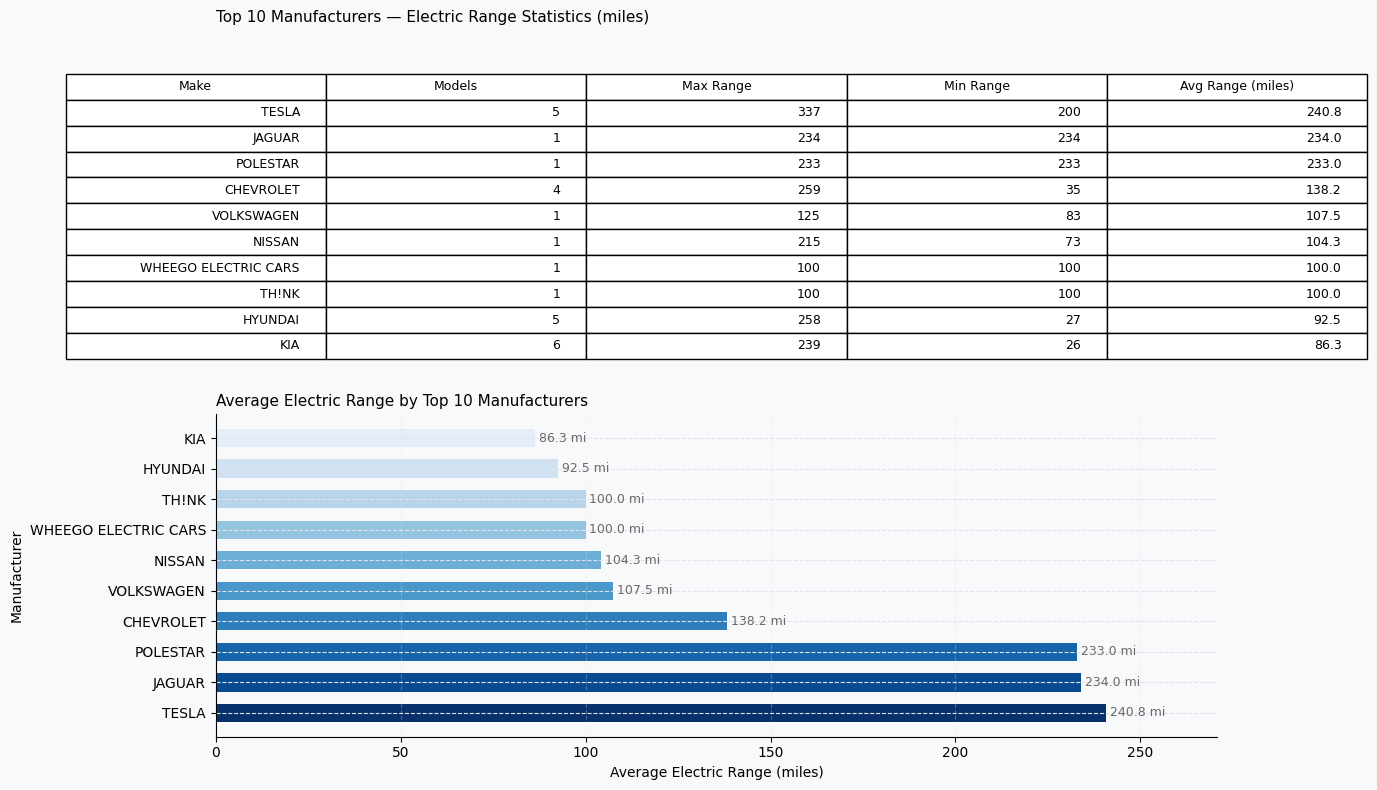

In [ ]:
# Exclude 0s (missing/unrecorded data)
range_df = df[df['Electric Range'] > 0]

# Array of Electric Range per Make and Model
make_model_range = (
    range_df.groupby(['Make', 'Model'])['Electric Range']
    .apply(list)
    .reset_index()
)
make_model_range.columns = ['Make', 'Model', 'Range Array']

# Average range per maker
avg_range = (
    range_df.groupby('Make')['Electric Range']
    .mean()
    .round(1)
    .reset_index()
)
avg_range.columns = ['Make', 'Avg Range (miles)']

# Top 10 by average range
top10_range = avg_range.sort_values('Avg Range (miles)', ascending=False).head(10)

# Also get model count and max range per maker for the table
stats = range_df.groupby('Make').agg(
    Models        = ('Model', 'nunique'),
    Max_Range     = ('Electric Range', 'max'),
    Min_Range     = ('Electric Range', 'min'),
    Avg_Range     = ('Electric Range', 'mean')
).round(1).reset_index()

stats.columns = ['Make', 'Models', 'Max Range', 'Min Range', 'Avg Range (miles)']
stats = stats[stats['Make'].isin(top10_range['Make'])]
stats = stats.sort_values('Avg Range (miles)', ascending=False)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                         gridspec_kw={'height_ratios': [1, 2]})

# ── TABLE (top) ───────────────────────────────────────────────────────────────
axes[0].axis('off')
axes[0].set_title(
    'Top 10 Manufacturers — Electric Range Statistics (miles)',
    fontsize=11, loc='left', pad=35
)

tbl = axes[0].table(
    cellText=stats.values,
    colLabels=stats.columns,
    loc='upper center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 1.8)

# ── HORIZONTAL BAR CHART (bottom) ────────────────────────────────────────────
colors = plt.cm.Blues_r(
    [i / len(top10_range) for i in range(len(top10_range))]
)

bars = axes[1].barh(
    stats['Make'],
    stats['Avg Range (miles)'],
    color=colors,
    height=0.6
)

# Annotate values on bars
for bar, val in zip(bars, stats['Avg Range (miles)']):
    axes[1].text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{val} mi",
        va='center', fontsize=9, color='dimgray'
    )

axes[1].set_title('Average Electric Range by Top 10 Manufacturers', fontsize=11, loc='left')
axes[1].set_xlabel('Average Electric Range (miles)')
axes[1].set_ylabel('Manufacturer')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim(0, stats['Avg Range (miles)'].max() + 30)

plt.tight_layout()
plt.show()

Your content is already strong — I’ve just refined it for clarity, grammar, consistency, and professional report tone while keeping your meaning intact:

---

## 1. EV Market Trend — BEV vs PHEV

* **BEVs dominate** the market with a significantly higher share (**~78%**) compared to PHEVs (**~21%**).
* Growth has been **exponential post-2019**, with BEVs showing the sharpest increase.
* PHEVs have remained relatively **stable with slow adoption growth** over time.

---

## 2. CAFV Eligibility

* A large portion of vehicles are **CAFV eligible**, indicating most EVs meet the required battery range criteria.
* **BEVs are almost entirely eligible**, confirming their higher battery capacity and compliance.
* **PHEVs contribute heavily to the “Not Eligible” category** due to lower electric range.
* A noticeable portion is marked as **“Unknown”**, indicating missing or incomplete data for some models.
* Tesla vehicles are split between **Eligible and Unknown (~30% vs ~70%)**, suggesting gaps in eligibility classification for newer models.

---

## 3. Top 10 Manufacturers

* **Tesla leads the market with ~49% share**, dominating total sales and electric range performance.
* Other key manufacturers include **Nissan, Chevrolet, Ford, BMW, Kia, Toyota, and Volkswagen**, collectively sharing the remaining market.
* Tesla models such as **Model Y (~40%) and Model 3 (~38%)** are the most dominant vehicles.
* Tesla shows consistently **higher CAFV eligibility rates** compared to competitors.
* Non-Tesla manufacturers generally show a **more balanced BEV and PHEV mix**.
* Tesla’s market share has **grown steadily since 2015**, with rapid acceleration after 2019.
* Despite overall industry growth, **no single competitor matches Tesla’s volume**, highlighting its strong market leadership.

---

## 4. Geographic Distribution — States, Counties, and Cities

* **Washington State dominates EV registrations**, which aligns with the dataset scope.

* A small number of states account for the **majority of EV adoption**.

* **King County leads all counties with 52%** in EV registrations.

* Top counties are primarily concentrated in **western Washington**.

* **Seattle with 16%, Bellevue with 5%, and Redmond with 3.6%** are the top EV cities.

* Urban cities show a **higher BEV concentration** compared to suburban and rural areas.

* PHEVs are slightly more common in areas with **longer commuting patterns**.

---

## 5. Urban vs Rural EV Adoption

* Urban areas dominate EV adoption, accounting for approximately **97% of total registrations**, driven by better infrastructure and higher population density.
* Rural areas contribute only around **3%**, due to limited charging infrastructure and lower accessibility.
* This confirms that EV adoption is **highly concentrated in urban regions** where usage conditions are more favorable.
* Overall, EV growth remains **strongly urban-centric**, with rural adoption still in early stages.

---

## 6. Electric Range

* **Tesla has the highest average electric range (~337 miles)** among all manufacturers.
* Newer model years consistently show **higher electric range improvements**.
* The most common non-zero range values reflect **mid-range BEV capabilities across the market**.

---

## Overall Conclusion

| Theme             | Finding                                                  |
| ----------------- | -------------------------------------------------------- |
| Market leader     | Tesla dominates with ~49% market share                   |
| Technology trend  | BEVs are rapidly replacing PHEVs                         |
| Policy compliance | BEVs largely meet CAFV eligibility, PHEVs lag behind     |
| Geography         | EV adoption is concentrated in urban, high-density areas |
| Range improvement | Electric range is steadily improving in newer models     |
| Growth trend      | EV adoption accelerates significantly after 2019         |
